# kmin Regression with ResNet50 (PyTorch)

**Goal**: Predict kmin from fractal cube images using regression.

**Memory optimized**: Lazy HDF5 loading, grayscale→RGB conversion on-the-fly.

In [1]:
from pathlib import Path
import json
import time

import h5py
import numpy as np
candidate_files = [
    Path("data/raw/flexible_20260425_221800_128x128_100000.h5")]
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm
OUTPUT_DIR = Path('../../outputs/kmax/regression')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
KMAX_MIN, KMAX_MAX = 100.0, 256.0

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
candidate_files = [
    Path('../../data/raw/flexible_20260425_221800_128x128_100000.h5'),
]

DATA_FILE = next((p for p in candidate_files if p.exists()), None)
OUTPUT_DIR = Path('../../outputs/kmin/regression')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 30
EARLY_STOP_PATIENCE = 15

KMIN_MIN, KMIN_MAX = 1.0, 32.0

if DATA_FILE is None:
    raise FileNotFoundError('Dataset not found')
print(f'Dataset: {DATA_FILE}')

Dataset: ../../data/raw/flexible_20260425_221800_128x128_100000.h5


## Memory-Efficient Dataset (Lazy Loading)

In [3]:
class HDF5Dataset(Dataset):
    """Lazy-loading HDF5 dataset - loads images on demand."""
    
    def __init__(self, h5_path, indices, kmin_values, kmin_min=1.0, kmin_max=32.0):
        self.h5_path = h5_path
        self.indices = indices
        self.kmin = kmin_values[indices]
        self.kmin_min = kmin_min
        self.kmin_max = kmin_max
        self._h5_file = None
    
    def _get_h5(self):
        if self._h5_file is None:
            self._h5_file = h5py.File(self.h5_path, 'r')
        return self._h5_file
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        h5 = self._get_h5()
        img_idx = self.indices[idx]
        
        # Load single image (grayscale)
        img = h5['images'][img_idx].astype(np.float32)
        
        # Normalize to [0, 1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        # Keep as 1 channel (1, H, W)
        img = img[np.newaxis, :, :]
        
        # Normalize target to [0, 1]
        y = (self.kmin[idx] - self.kmin_min) / (self.kmin_max - self.kmin_min)
        
        return torch.from_numpy(img), torch.tensor(y, dtype=torch.float32)
    
    def __del__(self):
        if self._h5_file is not None:
            self._h5_file.close()

In [4]:
# Only load metadata, not images
with h5py.File(DATA_FILE, 'r') as f:
    n_samples = f['images'].shape[0]
    kmin_values = f['parameters/k_min'][:]

print(f'Total samples: {n_samples}')
print(f'kmin range: [{kmin_values.min():.1f}, {kmin_values.max():.1f}]')
print(f'RAM usage: ~{kmin_values.nbytes / 1e6:.1f} MB (metadata only)')

Total samples: 100000
kmin range: [1.0, 32.0]
RAM usage: ~0.4 MB (metadata only)


In [5]:
# Split indices, not data
from sklearn.model_selection import train_test_split

indices = np.arange(n_samples)
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

# Create datasets with lazy loading
train_ds = HDF5Dataset(DATA_FILE, train_idx, kmin_values, KMIN_MIN, KMIN_MAX)
val_ds = HDF5Dataset(DATA_FILE, val_idx, kmin_values, KMIN_MIN, KMIN_MAX)
test_ds = HDF5Dataset(DATA_FILE, test_idx, kmin_values, KMIN_MIN, KMIN_MAX)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

Train: 80000, Val: 10000, Test: 10000


## Model

In [6]:
from torchvision import models

class ResNet50Regressor(nn.Module):
    def __init__(self, in_channels=1, pretrained=False):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        
        # Modify first conv to accept 1 channel instead of 3
        self.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.backbone(x).squeeze(-1)

model = ResNet50Regressor(in_channels=1, pretrained=False).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 24,042,817


In [7]:
criterion = nn.HuberLoss(delta=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)
scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

## Train

In [8]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        
        if scaler:
            with torch.amp.autocast('cuda'):
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        total_loss += loss.item() * len(X_batch)
        preds.append(pred.cpu())
        targets.append(y_batch.cpu())
    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mae = np.abs(preds - targets).mean()
    return total_loss / len(loader.dataset), mae, preds, targets

In [9]:
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
patience_counter = 0

start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_mae, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    
    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | MAE: {val_mae:.4f} | LR: {lr:.2e}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

train_time = time.time() - start_time
print(f'\nTraining: {train_time/60:.1f} min')  

Epoch   1 | Train: 0.0040 | Val: 0.0050 | MAE: 0.0875 | LR: 1.00e-04
Epoch   2 | Train: 0.0022 | Val: 0.0047 | MAE: 0.0814 | LR: 1.00e-04
Epoch   3 | Train: 0.0017 | Val: 0.0060 | MAE: 0.0982 | LR: 1.00e-04
Epoch   4 | Train: 0.0014 | Val: 0.0027 | MAE: 0.0586 | LR: 1.00e-04
Epoch   5 | Train: 0.0012 | Val: 0.0218 | MAE: 0.2519 | LR: 1.00e-04
Epoch   6 | Train: 0.0011 | Val: 0.0020 | MAE: 0.0486 | LR: 1.00e-04
Epoch   7 | Train: 0.0010 | Val: 0.0020 | MAE: 0.0479 | LR: 1.00e-04
Epoch   8 | Train: 0.0009 | Val: 0.0014 | MAE: 0.0374 | LR: 1.00e-04
Epoch   9 | Train: 0.0009 | Val: 0.0034 | MAE: 0.0616 | LR: 1.00e-04
Epoch  10 | Train: 0.0009 | Val: 0.0136 | MAE: 0.1624 | LR: 1.00e-04
Epoch  11 | Train: 0.0009 | Val: 0.0025 | MAE: 0.0538 | LR: 1.00e-04
Epoch  12 | Train: 0.0008 | Val: 0.0011 | MAE: 0.0312 | LR: 1.00e-04
Epoch  13 | Train: 0.0007 | Val: 0.0012 | MAE: 0.0371 | LR: 1.00e-04
Epoch  14 | Train: 0.0007 | Val: 0.0008 | MAE: 0.0295 | LR: 1.00e-04
Epoch  15 | Train: 0.0007 | Val: 0

## Evaluate

In [10]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pt'))
_, _, y_pred_norm, y_true_norm = eval_epoch(model, test_loader, criterion)

# Denormalize
y_pred = y_pred_norm * (KMIN_MAX - KMIN_MIN) + KMIN_MIN
y_true = y_true_norm * (KMIN_MAX - KMIN_MIN) + KMIN_MIN

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print('=== Test Metrics ===')
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²:   {r2:.4f}')

=== Test Metrics ===
MAE:  0.824
RMSE: 1.081
R²:   0.9853


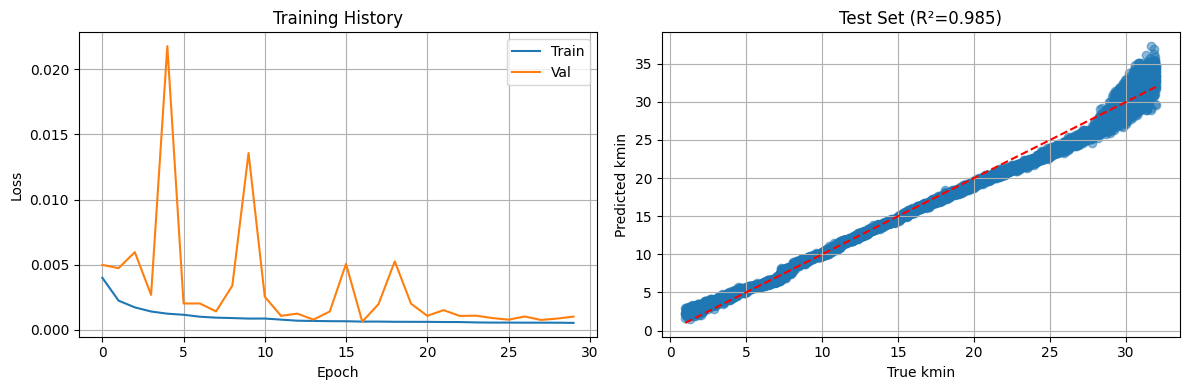

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training History')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel('True kmin')
plt.ylabel('Predicted kmin')
plt.title(f'Test Set (R²={r2:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
results = {
    'mae': float(mae),
    'rmse': float(rmse),
    'r2': float(r2),
    'param_range': [float(KMIN_MIN), float(KMIN_MAX)],
    'training_time_min': train_time / 60
}

with open(OUTPUT_DIR / 'test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

with open(OUTPUT_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print('Results saved to', OUTPUT_DIR)

TypeError: Object of type float32 is not JSON serializable